In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [ ]:
def load_images_from_dataset(dataset_path, image_size=(64, 64)):
    X, Y = [], []
    class_map = {"cars": 0, "bike": 1} # Matches your folder names

    for class_name, label in class_map.items():
        folder_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(folder_path): continue
        for filename in os.listdir(folder_path):
            try:
                img = Image.open(os.path.join(folder_path, filename)).convert('RGB').resize(image_size)
                X.append(np.array(img))
                Y.append(label)
            except: continue
    return np.array(X), np.array(Y).reshape((1, -1))

# Load and Normalize
dataset_path = r"/content/dataset"
X_orig, Y = load_images_from_dataset(dataset_path)
X_flatten = X_orig.reshape(X_orig.shape[0], -1).T / 255.

# 80/20 Train-Test Split
m = X_flatten.shape[1]
X, Y = shuffle(X_flatten.T, Y.T)
split = int(m * 0.8)
train_x, test_x = X[:split].T, X[split:].T
train_y, test_y = Y[:split].T, Y[split:].T

In [ ]:
#activation functions
def sigmoid(z):
    return 1/(1+np.exp(-z)),z
def relu(z):
    return np.maximum(0,z),z
def sigmoid_backward(da,cache):
    z=cache
    s=1/(1+np.exp(-z))
    return da*s*(1-s)
def relu_backward(da,cache):
    z=cache
    dz=np.array(da,copy=True)
    dz[z<=0]=0
    return dz


In [ ]:
#initialization and foward propagtaion
def initialize_parameters(layer_dims):
    parameters={}
    for l in range(1,len(layer_dims)):
        parameters['w'+str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])/np.sqrt(layer_dims[l-1])
        parameters['b'+str(l)]=np.zeros((layer_dims[l],1))
    return parameters
def forward(X,parameters):
    caches=[]
    a=X
    L=len(parameters)//2
    for l in range(1,L):
        a_prev=a
        z=np.dot(parameters['w'+str(l)],a_prev)+parameters['b'+str(l)]
        a,activation_cache=relu(z)
        caches.append(((a_prev,parameters['w'+str(l)],parameters['b'+str(l)]),activation_cache))
    zl=np.dot(parameters['w'+str(L)],a)+parameters['b'+str(L)]
    al,activation_cache=sigmoid(zl)
    caches.append(((a,parameters['w'+str(L)],parameters['b'+str(L)]),activation_cache))
    return al,caches

In [ ]:
#cost and backward propagation
def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = -(1/m) * np.sum(
        Y * np.log(AL + 1e-8) + (1 - Y) * np.log(1 - AL + 1e-8))
    return np.squeeze(cost)
def backward(AL, Y, caches):
    grads = {}
    L = len(caches)          # number of layers
    m = AL.shape[1]

    # derivative of cost w.r.t AL
    dAL = -(np.divide(Y, AL + 1e-8) - np.divide(1 - Y, 1 - AL + 1e-8))

    # ===== LAST LAYER (SIGMOID) =====
    current_cache = caches[L-1]
    linear_cache, activation_cache = current_cache

    dZ = sigmoid_backward(dAL, activation_cache)
    A_prev, W, b = linear_cache

    grads["dW" + str(L)] = (1/m) * np.dot(dZ, A_prev.T)
    grads["db" + str(L)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(W.T, dZ)

    # ===== HIDDEN LAYERS (RELU) =====
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        linear_cache, activation_cache = current_cache

        dZ = relu_backward(grads["dA" + str(l+1)], activation_cache)
        A_prev, W, b = linear_cache

        grads["dW" + str(l+1)] = (1/m) * np.dot(dZ, A_prev.T)
        grads["db" + str(l+1)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        grads["dA" + str(l)] = np.dot(W.T, dZ)

    return grads

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2

    for l in range(1, L+1):
        parameters["w" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    return parameters



In [ ]:
#model training
def n_layer_model(X,Y,layer_dims,l_r=0.0075,num_iterations=2500):
    parameters=initialize_parameters(layer_dims)
    costs=[]
    for i in range(num_iterations):
        al,caches=forward(X,parameters)
        cost=compute_cost(al,Y)
        grads=backward(al,Y,caches)
        parameters=update_parameters(parameters,grads,l_r)
        if i%100==0:
            print(f"cost after iteration{i}:{cost}")
            costs.append(cost)
    plt.plot(costs)
    plt.ylabel("Cost")
    plt.xlabel("Iterations (per 100)")
    plt.title("Training Cost Curve")
    plt.show()

    return parameters

In [ ]:
def predict(X,parameters):
    al,_=forward(X,parameters)
    predictions=(al>0.5).astype(int)
    return predictions

In [ ]:
def accuracy(preds,labels):
    return np.mean(preds==labels)*100

cost after iteration0:0.7308508516395181
cost after iteration100:0.5899577139394642
cost after iteration200:0.583934894974602
cost after iteration300:0.5786288831080201
cost after iteration400:0.573507529107571
cost after iteration500:0.5674491991563232
cost after iteration600:0.5563392484785481
cost after iteration700:0.5540690129791853
cost after iteration800:0.550376885493091
cost after iteration900:0.5476737208271182
cost after iteration1000:0.5433199923361027
cost after iteration1100:0.5411840706596216
cost after iteration1200:0.5377652231231214
cost after iteration1300:0.5357021867910841
cost after iteration1400:0.5332385707773375
cost after iteration1500:0.5277921515888613
cost after iteration1600:0.529960683047984
cost after iteration1700:0.5271768099970694
cost after iteration1800:0.5203302289784756
cost after iteration1900:0.5164117205879869
cost after iteration2000:0.5163978703897657
cost after iteration2100:0.5099736146940377
cost after iteration2200:0.508383449020878
cost 

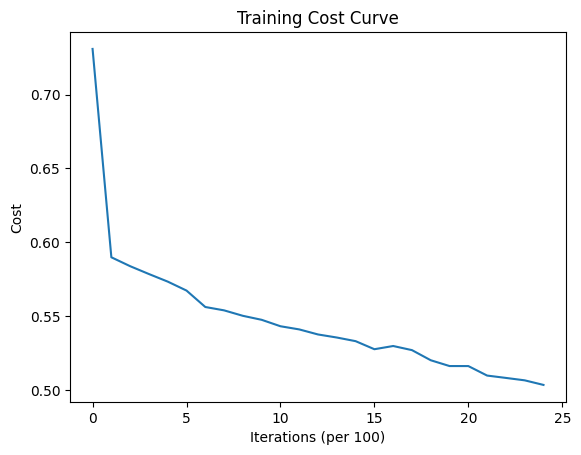

training accuracy:73.79%
testing accuracy:42.98%


In [ ]:
layer_dims = [12288, 20, 7, 5, 1]
parameters = n_layer_model(train_x, train_y, layer_dims)
train_preds=predict(train_x,parameters)
test_preds=predict(test_x,parameters)
train_acc=accuracy(train_preds,train_y)
test_acc=accuracy(test_preds,test_y)
print(f"training accuracy:{train_acc:.2f}%")
print(f"testing accuracy:{test_acc:.2f}%")

The model predicts this image is a: car


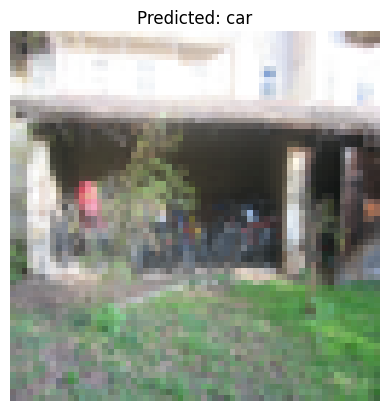

In [ ]:
import os
from PIL import Image
import numpy as np

# @title Enter the path to your image file
image_path = "/content/dataset/cars/bike_001.bmp" # @param {type:"string"}

if not os.path.exists(image_path):
    print(f"Error: The file at {image_path} does not exist. Please check the path and try again.")
else:
    try:
        # Load and preprocess the image
        test_image = Image.open(image_path).convert('RGB').resize((64, 64))
        test_image_flatten = np.array(test_image).reshape((1, -1)).T / 255.

        # Make a prediction
        single_image_prediction = predict(test_image_flatten, parameters)

        # Display the prediction
        class_names = {0: "car", 1: "bike"}
        predicted_class_label = single_image_prediction[0, 0]
        predicted_class_name = class_names[predicted_class_label]

        print(f"The model predicts this image is a: {predicted_class_name}")

        # Display the image for context
        plt.imshow(test_image)
        plt.title(f"Predicted: {predicted_class_name}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"An error occurred while processing the image: {e}")